# Run a Single Coupled Example - Dynamic Wflow -> SFINCS

Run one coupled Wflow-SFINCS event: Wflow starts from the prepared native instate, generates SFINCS inflow hydrographs, then SFINCS consumes that dynamic handoff.

Stage Contract
- Requires: built coupled Wflow/SFINCS bases, Event Catalog, warmup forcing/states from `b_prepare_wflow_dynamic_handoff.ipynb`, and reviewed source artifacts.
- Produces: dynamic Wflow `sfincs_discharge.nc`, dynamic handoff QA/acceptance, one staged SFINCS scenario folder, forcing QA plots, optional SFINCS outputs, and post-run diagnostics.
- Next: review diagnostics or batch scenarios in `../05_create_scenarios.ipynb`.


In [1]:
import json
import os
import warnings
from pathlib import Path

os.environ.pop("DEBUG", None)
os.environ.setdefault("MPLCONFIGDIR", "/tmp/flood-rm-matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
warnings.filterwarnings("ignore")

import pandas as pd
from IPython.display import HTML, Video, display

# standard paths and readiness tables.
from wflow_runs.notebook import load_runtime
# event selection, SFINCS staging, and handoff readiness.
from sfincs_runs.scenarios import (
    plan_example,
    stage_inland_coupled_example_forcing,
)
# stage one SFINCS run from the Event Catalog.
from sfincs_runs.scenarios.event_forcing import run_model
# review forcing, flood animations, and post-run checks.
from sfincs_runs.diagnostics import (
    plot_forcing,
    plot_diagnostics,
    plot_animation,
)
# meteo forcing, discharge handoff, and acceptance gates.
from wflow_runs import ensure_dynamic_handoff

runtime = load_runtime(Path("../..").resolve(), wflow_domain_review_required=False)
location_root = runtime.location_root
repo_root = runtime.repo_root
config = runtime.config
paths = runtime.paths
events_root = runtime.events_root


## 1 - Select a catalog event

`plan_example` checks the static/base-model contract and selects the catalog event used by both Wflow and SFINCS.


In [2]:
EVENT_ID = None  # None -> highest-RP catalog event; or e.g. "design_0398"
CATALOG_PATH = "data/event_catalog/catalog/probability_catalog.csv"

example_plan = plan_example(
    config,
    {"location_root": location_root},
    catalog_path=CATALOG_PATH,
    event_id=EVENT_ID,
)

plan_summary = pd.Series({
    "status": example_plan.status,
    "event_id": example_plan.event_id,
    "event_reference_time": example_plan.event_reference_time,
    "catalog_path": example_plan.catalog_path,
    "handoff_path": example_plan.handoff_path,
    "wflow_event_dir": example_plan.wflow_event_dir,
    "wflow_discharge_forcing": example_plan.wflow_discharge_forcing,
    "sfincs_scenario_dir": example_plan.sfincs_scenario_dir,
    "sfincs_dry_run_command": example_plan.sfincs_dry_run_command,
}, name="inland_coupled_example_plan")
display(plan_summary)

if example_plan.issues:
    print("Blocking issues (resolve upstream, then rerun):")
    for issue in example_plan.issues:
        print("  -", issue)
if example_plan.status != "ready":
    raise RuntimeError("Coupled example inputs are not ready; resolve the blocking issues above.")

event_id = example_plan.event_id
discharge_nc = events_root / event_id / "sfincs_discharge.nc"
event_precip_nc = events_root / event_id / "precip.nc"
acceptance_json = events_root / event_id / "sfincs_discharge.dynamic_handoff.json"


status                                                                 ready
event_id                                                         design_0499
event_reference_time                                     2008-08-27 10:00:00
catalog_path               /home/grahamhults/projects/Flood-RM/locations/...
handoff_path               /home/grahamhults/projects/Flood-RM/locations/...
wflow_event_dir                                data/wflow/events/design_0499
wflow_discharge_forcing    data/wflow/events/design_0499/sfincs_discharge.nc
sfincs_scenario_dir        /home/grahamhults/projects/Flood-RM/locations/...
sfincs_dry_run_command     uv run python -m sfincs_runs.scenarios.run_eve...
Name: inland_coupled_example_plan, dtype: str

## Rerun Control


In [3]:
rerun = True


## 2 - Run dynamic Wflow handoff

Run Wflow first from the prepared native `instate/instates.nc`. The accepted `sfincs_discharge.nc` produced here is the upstream boundary forcing that SFINCS consumes at its native `src` inflow points.


In [4]:
run_dynamic_wflow_handoff = True
handoff_run = ensure_dynamic_handoff(
    config,
    location_root,
    event_id,
    catalog_path=CATALOG_PATH,
    rerun=rerun,
    run=run_dynamic_wflow_handoff,
)

display(handoff_run.summary)
if handoff_run.meteo_report is not None:
    display(handoff_run.meteo_report)
if handoff_run.handoff_report is not None:
    display(handoff_run.handoff_report)

handoff_acceptance = handoff_run.acceptance
display(handoff_acceptance)


2026-06-28 12:22:32,552 - hydromt - log - INFO - HydroMT version: 1.3.1
2026-06-28 12:22:32,749 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from /home/grahamhults/projects/Flood-RM/locations/greensboro/data/wflow/events/design_0499/_replay_data_catalog.yml
2026-06-28 12:22:32,778 - hydromt.model.model - model - INFO - Initializing wflow_sbm model from hydromt_wflow (v1.0.2).
2026-06-28 12:22:32,778 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from /home/grahamhults/projects/Flood-RM/.venv/lib/python3.13/site-packages/hydromt_wflow/data/parameters_data.yml
2026-06-28 12:22:32,800 - hydromt.hydromt_wflow.wflow_base - wflow_base - INFO - Supported Wflow.jl version v1+
2026-06-28 12:22:32,800 - hydromt.hydromt_wflow.components.config - config - INFO - Reading model config file from /home/grahamhults/projects/Flood-RM/locations/greensboro/data/wflow/base/greensboro_rural/wflow_sbm.toml.
2026-06-28 12:22:32,801 - hydrom

┌ Warning: 'header' is not recognized as a valid field of the [input] section in the TOML, this will be ignored.
└ @ Wflow ~/.julia/packages/Wflow/mJ7Ug/src/config_init.jl:81
┌ Warning: 'params' is not recognized as a valid field of the [input] section in the TOML, this will be ignored.
└ @ Wflow ~/.julia/packages/Wflow/mJ7Ug/src/config_init.jl:81
[ Info: Wflow version v1.0.2
[ Info: Initialize model variables for model type sbm.
┌ Info: Cyclic parameters are provided by
└ /home/grahamhults/projects/Flood-RM/locations/greensboro/data/wflow/events/design_0499/greensboro_rural/staticmaps.nc.
┌ Info: Forcing parameters are provided by
└ /home/grahamhults/projects/Flood-RM/locations/greensboro/data/wflow/events/design_0499/greensboro_rural/inmaps-event.nc.
┌ Info: Set atmosphere_water__precipitation_volume_flux using netCDF variable
└ precip as forcing parameter.
┌ Info: Set atmosphere_air__temperature using netCDF variable temp as forcing
└ parameter.
┌ Info: Set land_surface_water__poten

event_id                                                       design_0499
dynamic_wflow_handoff                                                  run
rerun                                                                 True
wflow_instate_count                                                      1
acceptance_json          /home/grahamhults/projects/Flood-RM/locations/...
sfincs_discharge         /home/grahamhults/projects/Flood-RM/locations/...
handoff_issue                                                             
Name: dynamic_wflow_handoff_run, dtype: object

event_id                                                       design_0499
window_start                                           2008-08-25T10:00:00
window_end                                             2008-08-30T10:00:00
rainfall_source_nc       /home/grahamhults/projects/Flood-RM/locations/...
rainfall_scale_factor                                             1.557055
precip_path              /home/grahamhults/projects/Flood-RM/locations/...
temp_pet_path            /home/grahamhults/projects/Flood-RM/locations/...
precip_provenance        /home/grahamhults/projects/Flood-RM/locations/...
temp_pet_provenance      /home/grahamhults/projects/Flood-RM/locations/...
precip_written                                                        True
temp_pet_written                                                      True
Name: wflow_event_meteo_forcing, dtype: object

,event_id,submodel_id,window_start,window_end,update_command,resolved_update_command,hydromt_runner_status,hydromt_runner_issue,run_command,run_output_dir,status,sfincs_discharge_forcing,sfincs_discharge_written,sfincs_discharge_source,dynamic_handoff_acceptance,acceptance_status
0,design_0499,greensboro_rural,2008-08-25T10:00:00,2008-08-30T10:00:00,hydromt update wflow_sbm /home/grahamhults/pro...,/home/grahamhults/projects/Flood-RM/.venv/bin/...,project_venv,,wflow_cli /home/grahamhults/projects/Flood-RM/...,/home/grahamhults/projects/Flood-RM/locations/...,completed,/home/grahamhults/projects/Flood-RM/locations/...,True,wflow_dynamic,/home/grahamhults/projects/Flood-RM/locations/...,accepted


event_id                                                            design_0499
status                                                                 accepted
discharge_source                                                  wflow_dynamic
sfincs_discharge_forcing      /home/grahamhults/projects/Flood-RM/locations/...
dynamic_handoff_acceptance    /home/grahamhults/projects/Flood-RM/locations/...
Name: dynamic_wflow_handoff_acceptance, dtype: str

## 3 - Configure SFINCS run


In [5]:
config["scenario_run"]["threads"] = 8
run_sfincs_solver = True

display(pd.Series({
    "dynamic_wflow_handoff": "accepted",
    "sfincs_solver": "run" if run_sfincs_solver else "stage forcing only",
    "sfincs_threads": config["scenario_run"]["threads"],
}, name="interactive_model_run"))

dynamic_wflow_handoff    accepted
sfincs_solver                 run
sfincs_threads                  8
Name: interactive_model_run, dtype: object

## 4 - Stage SFINCS and apply rainfall + dynamic Wflow discharge


In [6]:
forcing_stage = stage_inland_coupled_example_forcing(
    config,
    {"location_root": location_root},
    example_plan=example_plan,
    event_id=event_id,
    force=rerun,
)

scenario_report = forcing_stage.scenario_report
sfincs_report = forcing_stage.sfincs_report
sim = forcing_stage.sim

display(scenario_report[["event_id", "sfincs_domain_id", "scenario_status", "run_root", "wflow_discharge_forcing"]])
display(sfincs_report[["event_id", "sfincs_domain_id", "status", "n_src", "run_root", "wflow_discharge_forcing"]])
for _, row in sfincs_report.iterrows():
    print(f"{row['sfincs_domain_id']}: staged forcing written; run pre-run QA before launching SFINCS.")


2026-06-28 12:24:14,894 - hydromt.model.model - model - INFO - Initializing sfincs model from hydromt_sfincs (v2.0.0rc1).
2026-06-28 12:24:14,895 - hydromt.model.model - model - WARNING - No region component found in components.
2026-06-28 12:24:15,001 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: mask
2026-06-28 12:24:15,004 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: dep
2026-06-28 12:24:15,006 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: manning
2026-06-28 12:24:15,008 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: smax
2026-06-28 12:24:15,011 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: seff
2026-06-28 12:24:15,015 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: ks
2026-06-28 12:24:16,338 - hydromt.hydromt_sfincs.components.output - output - WARNING - File /home/grahamhults/projects/Flood-RM/locations/greensboro/data/sfincs/scenarios

,event_id,sfincs_domain_id,scenario_status,run_root,wflow_discharge_forcing
0,design_0499,greensboro_rural,written,/home/grahamhults/projects/Flood-RM/locations/...,data/wflow/events/design_0499/sfincs_discharge.nc


,event_id,sfincs_domain_id,status,n_src,run_root,wflow_discharge_forcing
0,design_0499,greensboro_rural,staged,3,/home/grahamhults/projects/Flood-RM/locations/...,/home/grahamhults/projects/Flood-RM/locations/...


greensboro_rural: staged forcing written; run pre-run QA before launching SFINCS.


## 5 - Wflow handoff output

Review the dynamic Wflow response that is handed to SFINCS: source peak discharge, staged rainfall total when direct rainfall is enabled, and handoff hydrographs.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


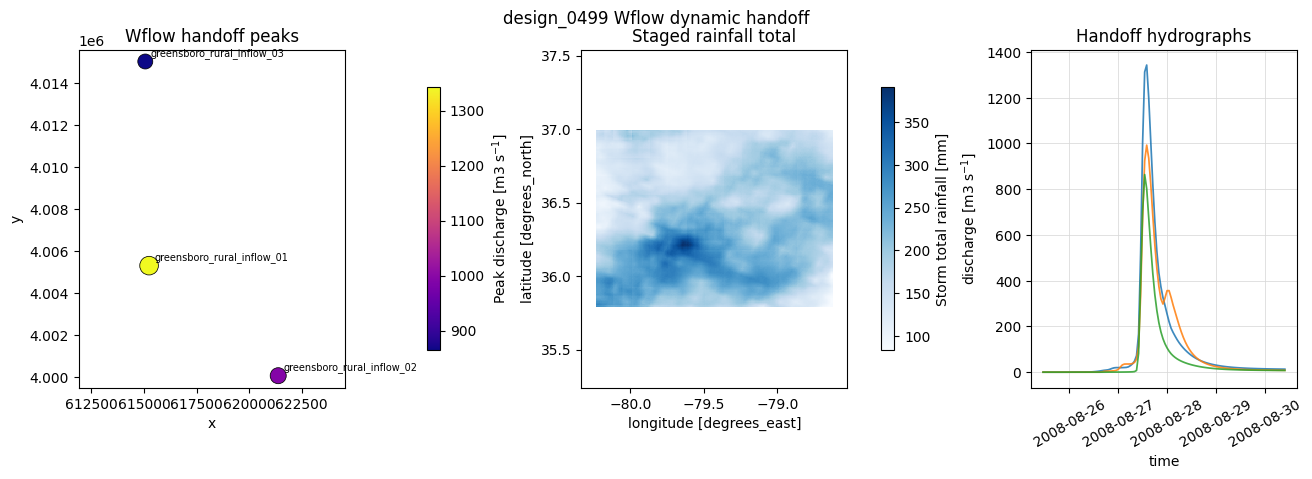

In [7]:
from wflow_runs import plot_wflow_event_handoff

precip_for_plot = event_precip_nc if event_precip_nc.exists() else None
fig, axes = plot_wflow_event_handoff(
    discharge_nc,
    precipitation_nc=precip_for_plot,
    event_label=event_id,
)


## 6 - Pre-run forcing QA


event                                         design_0499 · greensboro_rural
run_root                   /home/grahamhults/projects/Flood-RM/locations/...
forcing_mode                                            dual_fluvial_pluvial
direct_rainfall_enabled                                                False
wflow_discharge_forcing    /home/grahamhults/projects/Flood-RM/locations/...
rainfall_member_id                          rainfall_greensboro_72h_rank0003
soil_moisture_member_id                        soil_moisture_20080824T120000
Name: inland_forcing_summary, dtype: object

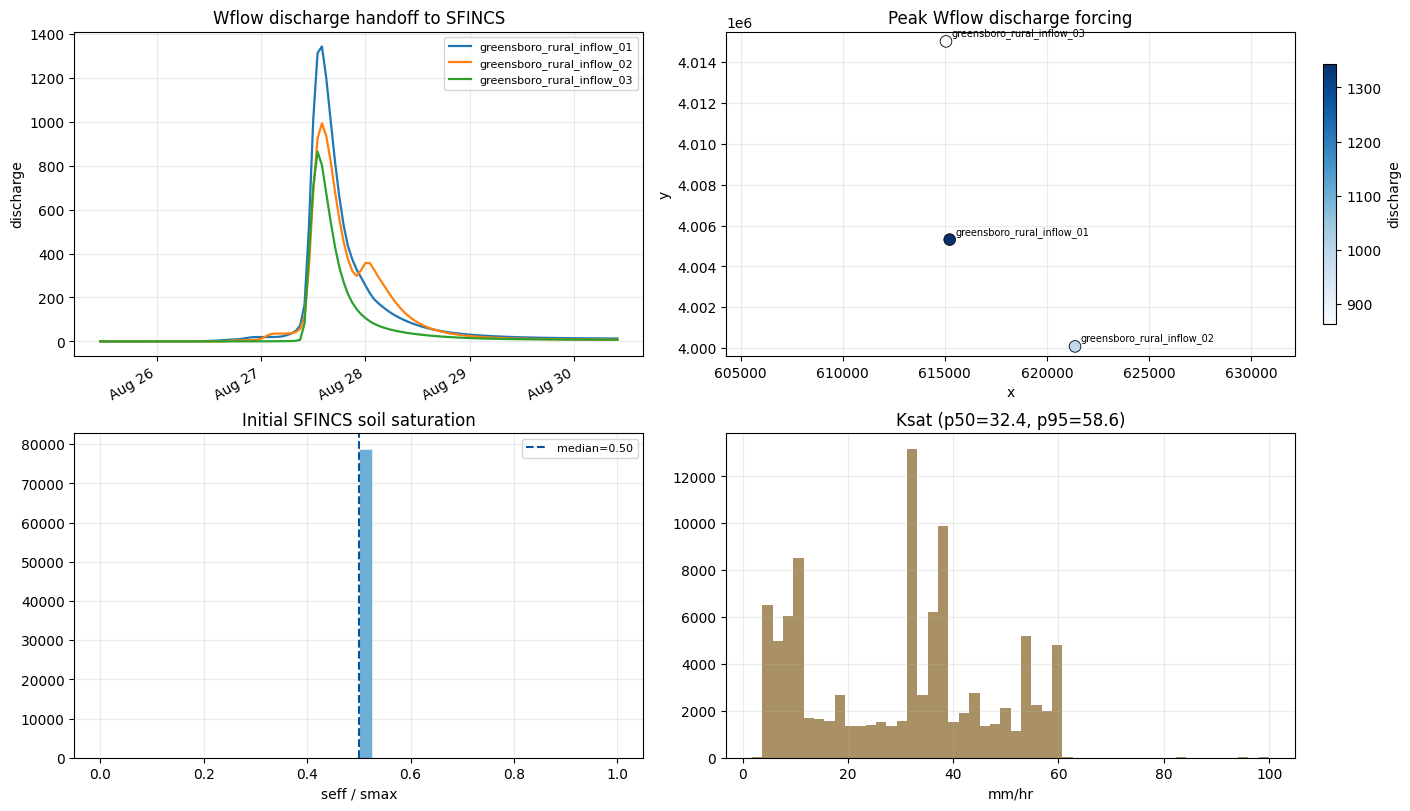

Saved inland forcing QA plot: /home/grahamhults/projects/Flood-RM/locations/greensboro/data/sfincs/scenarios/design_0499/greensboro_rural/diagnostics/design_0499_inland_forcing_qa.png


In [8]:
for domain_id, s in sim.items():
    plot_forcing(
        forcing_manifest=s["run_dir"] / "forcing_manifest.json",
        event_id=event_id,
        event_label=f"{event_id} · {domain_id}",
    )

if not sim:
    print("No example runs — nothing to QA.")


## 7 - Run SFINCS


In [9]:
if run_sfincs_solver:
    sfincs_rows = []
    for domain_id, s in sim.items():
        run_dir = s["run_dir"]
        result = run_model(run_dir, config=config)
        s["result"] = result
        manifest_path = run_dir / "forcing_manifest.json"
        manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
        manifest["sfincs_run_executed"] = True
        manifest_path.write_text(json.dumps(manifest, indent=2, sort_keys=True) + "\n", encoding="utf-8")
        sfincs_rows.append({
            "event_id": event_id,
            "sfincs_domain_id": domain_id,
            "status": "completed",
            "n_src": int(s["dis"].sizes.get("index", 0)),
            "run_root": str(run_dir),
            "map_written": result.map_path.exists(),
        })
    sfincs_run_report = pd.DataFrame(sfincs_rows)
    display(sfincs_run_report[["event_id", "sfincs_domain_id", "status", "n_src", "run_root", "map_written"]])
else:
    print("SFINCS solver skipped; staged forcing and QA are available for review.")


,event_id,sfincs_domain_id,status,n_src,run_root,map_written
0,design_0499,greensboro_rural,completed,3,/home/grahamhults/projects/Flood-RM/locations/...,True


## 8 - Flood + discharge animation (mp4)


Frames: 120
Peak flooded area: 33.56 km² at 2008-08-27 21:00:00
Peak inflow: 3138.5 m³/s
Display depth threshold: 5 cm  (HUTHRESH=2 cm)


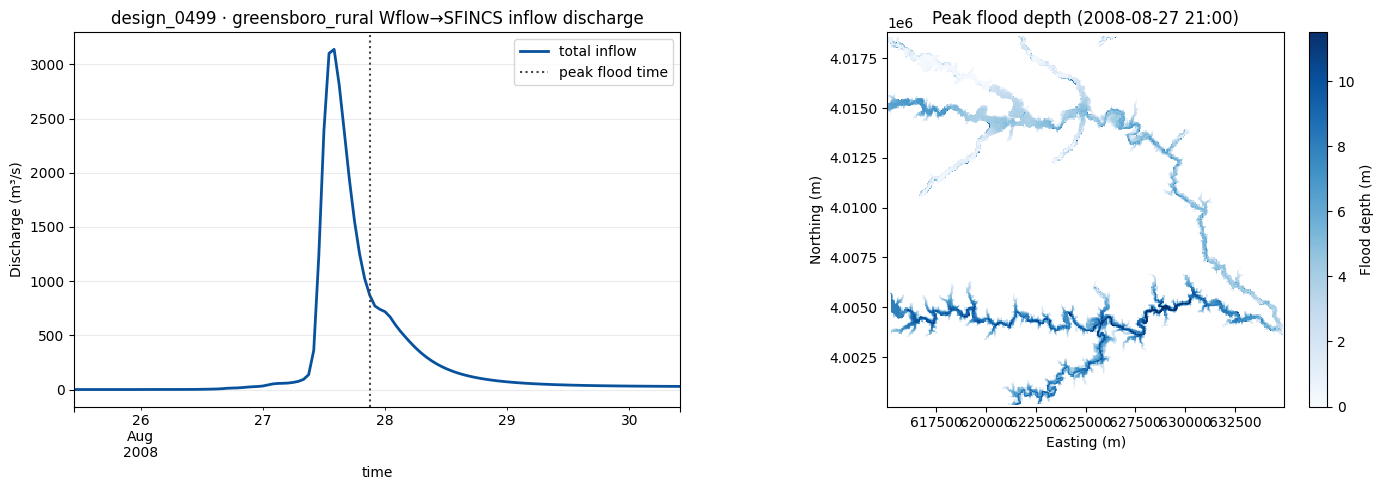

Saved animation: /home/grahamhults/projects/Flood-RM/locations/greensboro/data/sfincs/scenarios/design_0499/greensboro_rural/figures/design_0499_flood_discharge_animation.mp4


In [10]:
for domain_id, s in sim.items():
    discharge_df = s["dis"].transpose("time", "index").to_pandas()
    out_mp4 = plot_animation(
        run_root=s["run_dir"],
        out_dir=s["run_dir"] / "figures",
        event_id=event_id,
        event_label=f"{event_id} · {domain_id}",
        discharge=discharge_df,
        t_start=s["t_start"],
    )
    display(HTML(f"<h4>{event_id} · {domain_id} — flood + discharge animation</h4>"))
    display(Video(str(out_mp4), embed=True))

if not sim:
    print("No example runs — nothing to animate.")
